In [ ]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("parisrohan/credit-score-classification")
print("Os arquivos foram baixados em:", path)

Using Colab cache for faster access to the 'credit-score-classification' dataset.
Os arquivos foram baixados em: /kaggle/input/credit-score-classification


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
caminho_treino = '/kaggle/input/credit-score-classification/train.csv'
df = pd.read_csv(caminho_treino)
df.head()

/tmp/ipykernel_4286/2700077952.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_treino)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
print(df['Age'].unique()[:30])

['23' '-500' '28_' '28' '34' '54' '55' '21' '31' '33' '34_' '7580' '30'
 '30_' '24' '24_' '44' '45' '40' '41' '32' '33_' '35' '35_' '36' '39' '37'
 '181' '20' '46']


In [ ]:
df['Age'] = df['Age'].str.strip('_')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
print(df['Age'].unique()[:30])

[  23 -500   28   34   54   55   21   31   33 7580   30   24   44   45
   40   41   32   35   36   39   37  181   20   46   26   42   19   48
  995   38]


In [ ]:
filtro_absurdo = (df['Age'] < 18) | (df['Age'] > 100)
quantidade_absurdo = df[filtro_absurdo].shape[0]
print(f"Quantidade de idades com valores absurdos na coluna 'Age': {quantidade_absurdo} de um total de {len(df)}")

Quantidade de idades com valores absurdos na coluna 'Age': 8482 de um total de 100000


In [ ]:
#Cálculo da mediana das idades entre 18 e 100
mediana_idade = df[(df['Age'] >= 18) & (df['Age'] <= 100)]['Age'].median()
print(f"A idade mediana calculada foi: {mediana_idade} anos")

#Método .loc para localizar as idades fora do padrão e substituir pela mediana.
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = mediana_idade

filtro_pos_limpeza = (df['Age'] < 18) | (df['Age'] > 100)
quantidade_pos_limpeza = df[filtro_pos_limpeza].shape[0]
print(f"Quantidade de idades com valores absurdos na coluna 'Age': {quantidade_pos_limpeza}")


A idade mediana calculada foi: 34.0 anos
Quantidade de idades com valores absurdos na coluna 'Age': 0


In [ ]:
print(df['Annual_Income'].unique()[:30])

['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89' '30689.89_'
 '35547.71_' '35547.71' '73928.46' '131313.4' '10909427.0' '34081.38_'
 '34081.38' '114838.41' '114838.41_' '31370.8' '33751.27' '88640.24'
 '88640.24_' '54392.16' '54392.16_' '8701.545' '8701.545_' '25546.26'
 '25546.26_' '31993.78' '92047.08' '92047.08_' '32284.62' '97791.42']


In [ ]:
# Remove o caractere '_' do início ou fim das strings na coluna Annual_Income
df['Annual_Income'] = df['Annual_Income'].str.strip('_')

# Converte a coluna para tipo numérico (float/decimal).
# Se houver qualquer outro texto bizarro escondido nas 100.000 linhas, ele virará NaN
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

# Auditoria - Contar se algum registro virou NaN por erro de conversão
erros_conversao = df['Annual_Income'].isna().sum()
print(f"Quantidade de linhas que falharam na conversão e viraram NaN: {erros_conversao}")

Quantidade de linhas que falharam na conversão e viraram NaN: 0


In [ ]:
# Exibe o resumo estatístico completo da coluna Annual_Income
print(df['Annual_Income'].describe().round(2))

count      100000.00
mean       176415.70
std       1429618.05
min          7005.93
25%         19457.50
50%         37578.61
75%         72790.92
max      24198062.00
Name: Annual_Income, dtype: float64


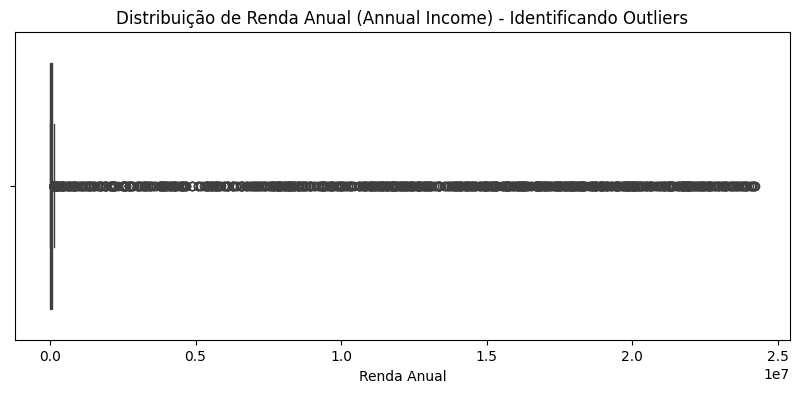

In [ ]:
# Figura para o gráfico
plt.figure(figsize=(10, 4))

# Boxplot da renda anual usando o Seaborn
sns.boxplot(x=df['Annual_Income'])

# Título explicativo
plt.title('Distribuição de Renda Anual (Annual Income) - Identificando Outliers')
plt.xlabel('Renda Anual')

# Gráfico na tela
plt.show()

In [ ]:
# Primeiro e o terceiro quartil da coluna
q1 = df['Annual_Income'].quantile(0.25)
q3 = df['Annual_Income'].quantile(0.75)

# Amplitude interquartil (IQR)
iqr = q3 - q1

# Limite Superior matemático
limite_superior = q3 + (1.5 * iqr)
print(f"O teto estatístico calculado para a renda foi de: {limite_superior.round(2)}")

# Quantas linhas estão acima desse limite estatístico
outliers_renda = df[df['Annual_Income'] > limite_superior].shape[0]
print(f"Quantidade de registros acima do limite superior: {outliers_renda}")

O teto estatístico calculado para a renda foi de: 152791.05
Quantidade de registros acima do limite superior: 2783


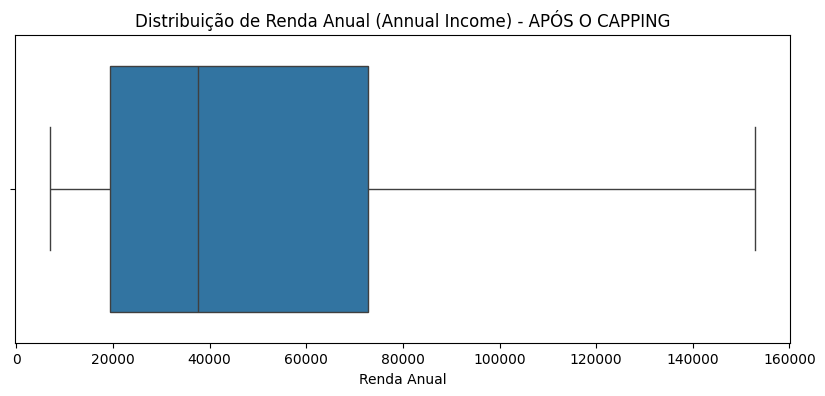

In [ ]:
# Onde a renda for maior que o teto, será substituído pelo próprio valor do teto
df.loc[df['Annual_Income'] > 152791.05, 'Annual_Income'] = 152791.05

# Gera o novo boxplot para conferir o resultado visual
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Annual_Income'])
plt.title('Distribuição de Renda Anual (Annual Income) - APÓS O CAPPING')
plt.xlabel('Renda Anual')
plt.show()

In [ ]:
print(df['Num_of_Loan'].unique()[:30])

['4' '1' '3' '967' '-100' '0' '0_' '2' '3_' '2_' '7' '5' '5_' '6' '8' '8_'
 '9' '9_' '4_' '7_' '1_' '1464' '6_' '622' '352' '472' '1017' '945' '146'
 '563']


In [ ]:

df['Num_of_Loan'] = df['Num_of_Loan'].astype(str).str.strip('_')

df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'], errors='coerce')

# Mediana apenas dos valores plausíveis (de 0 a 10 empréstimos)
mediana_loans = df[(df['Num_of_Loan'] >= 0) & (df['Num_of_Loan'] <= 10)]['Num_of_Loan'].median()
print(f"A mediana real de empréstimos é: {mediana_loans}")

# O que for menor que 0 OU maior que 10 vira a Mediana
df.loc[(df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 10), 'Num_of_Loan'] = mediana_loans

# Conferindo se sobrou algum valor absurdo
print("\nValores únicos na coluna após a limpeza completa:")
print(df['Num_of_Loan'].unique())

A mediana real de empréstimos é: 3.0

Valores únicos na coluna após a limpeza completa:
[4 1 3 0 2 7 5 6 8 9]


In [ ]:
df['Num_of_Delayed_Payment'].unique()[:30]


array(['7', nan, '4', '8_', '6', '1', '-1', '3_', '0', '8', '5', '3', '9',
       '12', '15', '17', '10', '2', '2_', '11', '14', '20', '22', '13',
       '13_', '14_', '16', '12_', '18', '19'], dtype=object)

In [ ]:
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].astype(str).str.strip('_')
df['Num_of_Delayed_Payment'] = pd.to_numeric(df['Num_of_Delayed_Payment'], errors='coerce')

# O Raio-X Estatístico
print("--- Resumo Estatístico Antes do Tratamento de Outliers ---")
print(df['Num_of_Delayed_Payment'].describe())

--- Resumo Estatístico Antes do Tratamento de Outliers ---
count    92998.000000
mean        30.923342
std        226.031892
min         -3.000000
25%          9.000000
50%         14.000000
75%         18.000000
max       4397.000000
Name: Num_of_Delayed_Payment, dtype: float64


In [ ]:
# Tratando as anomalias numéricas e nulos
# Mediana apenas dos valores normais (maiores ou iguais a zero)
mediana_atrasos = df[df['Num_of_Delayed_Payment'] >= 0]['Num_of_Delayed_Payment'].median()

# Substituir os valores negativos pela mediana
df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = mediana_atrasos

# Substituir os valores nulos (NaN) pela mediana
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(mediana_atrasos)

print("\n--- Valores Únicos Finais Após a Limpeza ---")
print(sorted(df['Num_of_Delayed_Payment'].unique()))


--- Valores Únicos Finais Após a Limpeza ---
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(46.0), np.float64(47.0), np.float64(49.0), np.float64(52.0), np.float64(72.0), np.float64(80.0), np.float64(84.0), np.float64(85.0), np.float64(86.0), np.float64(88.0), np.float64(94.0), np.float64(98.0), np.float64(102.0), np.float64(106.0), np.float64(107.0), np.float64(121.0), np.float64(130.0), np.float64(132.0), np.float64(133.0), np.float64(142.0), np.float64(145.0), np.float64(162.0), np.float64(166.0), np.float64(175.0

In [ ]:
# 1. Mediana apenas dos valores plausíveis de mercado (entre 0 e 28 atrasos)
mediana_atrasos = df[(df['Num_of_Delayed_Payment'] >= 0) & (df['Num_of_Delayed_Payment'] <= 28)]['Num_of_Delayed_Payment'].median()
print(f"A mediana justa calculada para pagamentos atrasados é: {mediana_atrasos}")

# 2. Tudo que for menor que 0 OU maior que 28 recebe a mediana
df.loc[(df['Num_of_Delayed_Payment'] < 0) | (df['Num_of_Delayed_Payment'] > 28), 'Num_of_Delayed_Payment'] = mediana_atrasos

# 3. Substitui eventuais valores nulos (NaN) pela mediana também
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(mediana_atrasos)

# 4. Lista final purificada
print("\n--- Lista de Valores Únicos Após o Tratamento Definitivo ---")
print(sorted(df['Num_of_Delayed_Payment'].unique()))

A mediana justa calculada para pagamentos atrasados é: 14.0

--- Lista de Valores Únicos Após o Tratamento Definitivo ---
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0)]


In [ ]:
print(df['Outstanding_Debt'].unique()[:30])

['809.98' '605.03' '1303.01' '632.46' '943.86' '548.2' '352.16' '1704.18'
 '1377.74' '421.43' '1328.93' '1328.93_' '950.36' '179.22' '2602.69'
 '758.44' '818.22' '1296.64' '1283.37' '1283.37_' '107.41' '2430.21'
 '881.4' '1672.43' '76.23' '569.8' '3532.83' '614.6' '2686.81' '1233.1']


In [ ]:
# Limpeza de texto e conversão segura para numérico
df['Outstanding_Debt'] = df['Outstanding_Debt'].astype(str).str.strip('_')
df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')

# Raio-X Estatístico para caçar anomalias numéricas ocultas
print("--- Resumo Estatístico de Outstanding_Debt ---")
print(df['Outstanding_Debt'].describe().round(2))

--- Resumo Estatístico de Outstanding_Debt ---
count    100000.00
mean       1426.22
std        1155.13
min           0.23
25%         566.07
50%        1166.16
75%        1945.96
max        4998.07
Name: Outstanding_Debt, dtype: float64


In [ ]:
print(df['Amount_invested_monthly'].unique()[:30])

['80.41529543900253' '118.28022162236736' '81.699521264648'
 '199.4580743910713' '41.420153086217326' '62.430172331195294'
 '178.3440674122349' '24.785216509052056' '104.291825168246'
 '40.39123782853101' '58.51597569589465' '99.30622796053305'
 '130.11542024292334' '43.477190144355745' '70.10177420755677'
 '218.90434353388733' '168.413702679309' '232.86038375993544' '__10000__'
 '825.2162699393922' '430.9475278803298' '257.80809942568976'
 '263.17416316163934' '81.22885871073616' '124.88181990234848'
 '83.40650880252501' '272.3340373956682' '84.95284817115969'
 '71.28367488286933' '125.61725053231268']


In [ ]:
# Forçar para string e limpar TODOS os underlines das pontas
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(str).str.strip('_')

# Converter para numérico (float)
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')

# O Raio-X Estatístico para analisar a distribuição
print("--- Resumo Estatístico de Amount_invested_monthly ---")
print(df['Amount_invested_monthly'].describe().round(2))

--- Resumo Estatístico de Amount_invested_monthly ---
count    95521.00
mean       637.41
std       2043.32
min          0.00
25%         74.53
50%        135.93
75%        265.73
max      10000.00
Name: Amount_invested_monthly, dtype: float64


In [ ]:
# Mediana apenas dos valores normais e realistas (abaixo de 1000)
mediana_investido = df[df['Amount_invested_monthly'] < 1000]['Amount_invested_monthly'].median()
print(f"A mediana real calculada para investimentos é: {mediana_investido:.2f}")

# Qualquer valor absurdo (acima de 1000) recebe a mediana
df.loc[df['Amount_invested_monthly'] > 1000, 'Amount_invested_monthly'] = mediana_investido

# Preenche os 4.479 valores nulos (NaN) com essa mesma mediana
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(mediana_investido)

# Novo resumo estatístico consolidado
print("\n--- Resumo Estatístico Pós-Tratamento ---")
print(df['Amount_invested_monthly'].describe().round(2))

A mediana real calculada para investimentos é: 127.62

--- Resumo Estatístico Pós-Tratamento ---
count    100000.00
mean        179.71
std         163.99
min           0.00
25%          77.02
50%         127.62
75%         213.77
max         999.86
Name: Amount_invested_monthly, dtype: float64


In [ ]:
print(df['Monthly_Balance'].unique()[:30])

['312.49408867943663' '284.62916249607184' '331.2098628537912'
 '223.45130972736786' '341.48923103222177' '340.4792117872438'
 '244.5653167062043' '358.12416760938714' '470.69062692529184'
 '484.5912142650067' '466.46647639764313' '465.6762241330048'
 '444.8670318506144' '481.505261949182' '464.8806778859809'
 '356.07810855965045' '1043.3159778669492' '998.8692967863226'
 '715.741367403555' '426.5134106068658' '810.7821526659284'
 '963.9215811205684' '968.5555173846187' '895.494583180492'
 '433.6047729627723' '409.95181177115995' '411.42712287098345'
 '262.4995942778403' '359.37491550776383' '419.8807835023488']


In [ ]:
df['Monthly_Balance'] = df['Monthly_Balance'].astype(str).str.strip('_')
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')

print("--- Resumo Estatístico de Monthly_Balance ---")
print(df['Monthly_Balance'].describe().round(2))

--- Resumo Estatístico de Monthly_Balance ---
count    9.880000e+04
mean    -3.036437e+22
std      3.181295e+24
min     -3.333333e+26
25%      2.700900e+02
50%      3.367200e+02
75%      4.702200e+02
max      1.602040e+03
Name: Monthly_Balance, dtype: float64


In [ ]:
# Mediana apenas dos saldos positivos e realistas
mediana_saldo = df[df['Monthly_Balance'] >= 0]['Monthly_Balance'].median()
print(f"A mediana real do saldo mensal é: {mediana_saldo:.2f}")

# Tudo que for menor que 0 recebe a mediana
df.loc[df['Monthly_Balance'] < 0, 'Monthly_Balance'] = mediana_saldo

# Tratamento de nulos
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(mediana_saldo)

print("\n--- Resumo Estatístico de Monthly_Balance (100% LIMPO) ---")
print(df['Monthly_Balance'].describe().round(2))

A mediana real do saldo mensal é: 336.73

--- Resumo Estatístico de Monthly_Balance (100% LIMPO) ---
count    100000.00
mean        401.76
std         212.75
min           0.01
25%         270.91
50%         336.73
75%         467.67
max        1602.04
Name: Monthly_Balance, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   ob

--- Média de Pagamentos Atrasados por Categoria de Score ---
  Credit_Score  Num_of_Delayed_Payment
0         Good                    9.23
1         Poor                   15.74
2     Standard                   13.65
------------------------------------------------------------


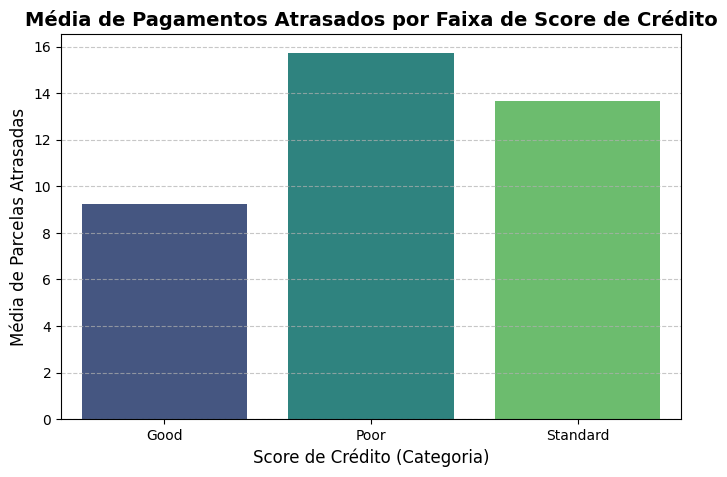

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupamento por Credit_Score e cálculo da média de parcelas atrasadas
analise_atrasos = df.groupby('Credit_Score')['Num_of_Delayed_Payment'].mean().reset_index()

print("--- Média de Pagamentos Atrasados por Categoria de Score ---")
print(analise_atrasos.round(2))
print("-" * 60)

# Gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(data=analise_atrasos, x='Credit_Score', y='Num_of_Delayed_Payment', hue='Credit_Score', legend=False, palette='viridis')

plt.title('Média de Pagamentos Atrasados por Faixa de Score de Crédito', fontsize=14, fontweight='bold')
plt.xlabel('Score de Crédito (Categoria)', fontsize=12)
plt.ylabel('Média de Parcelas Atrasadas', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


--- Médias Financeiras por Categoria de Score ---
  Credit_Score  Monthly_Balance  Amount_invested_monthly
0         Good           473.92                   215.41
1         Poor           345.56                   154.65
2     Standard           408.21                   181.40
------------------------------------------------------------


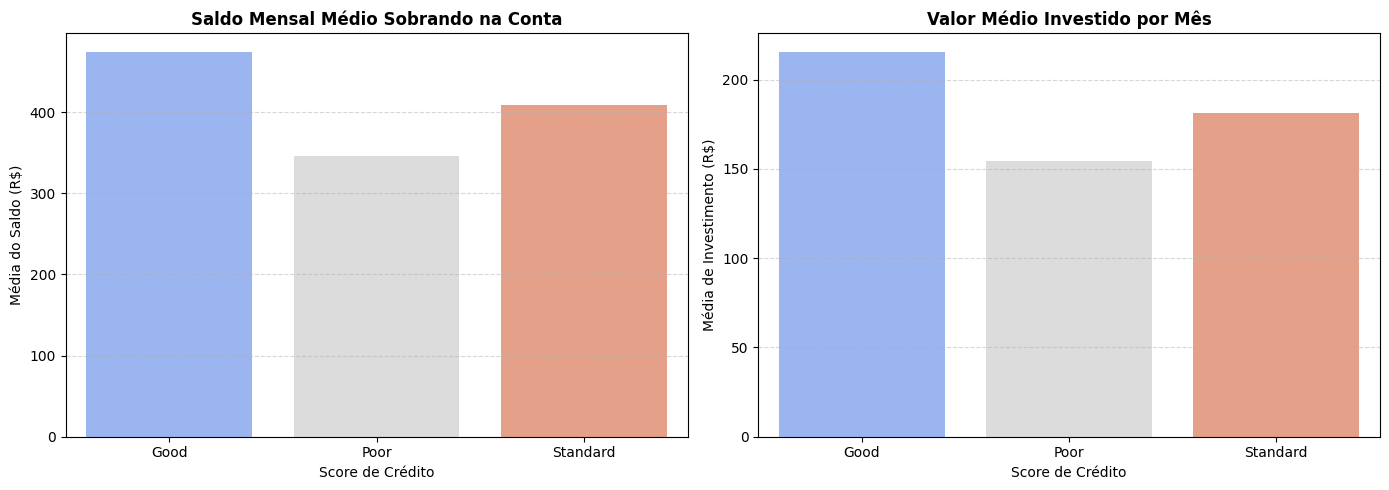

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupamento dos dados para extrair as médias financeiras
analise_financeira = df.groupby('Credit_Score')[['Monthly_Balance', 'Amount_invested_monthly']].mean().reset_index()
print("--- Médias Financeiras por Categoria de Score ---")
print(analise_financeira.round(2))
print("-" * 60)

# Configuração do painel com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Saldo Mensal Médio
sns.barplot(data=analise_financeira, x='Credit_Score', y='Monthly_Balance',
            hue='Credit_Score', palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_title('Saldo Mensal Médio Sobrando na Conta', fontweight='bold')
axes[0].set_xlabel('Score de Crédito')
axes[0].set_ylabel('Média do Saldo (R$)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Gráfico 2: Valor Investido Mensal Médio
sns.barplot(data=analise_financeira, x='Credit_Score', y='Amount_invested_monthly',
            hue='Credit_Score', palette='coolwarm', legend=False, ax=axes[1])
axes[1].set_title('Valor Médio Investido por Mês', fontweight='bold')
axes[1].set_xlabel('Score de Crédito')
axes[1].set_ylabel('Média de Investimento (R$)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Verificando as categorias de Mix de Crédito existentes
print("Categorias únicas em Credit_Mix:")
print(df['Credit_Mix'].unique())

# Vendo a distribuição de clientes em cada uma
print("\nDistribuição da base por categoria:")
print(df['Credit_Mix'].value_counts())

Categorias únicas em Credit_Mix:
['_' 'Good' 'Standard' 'Bad']

Distribuição da base por categoria:
Credit_Mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64


In [ ]:
# Substituindo o caractere '_' pela categoria mais frequente ('Standard')
df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Standard')

# Dicionário para converter texto em números com hierarquia ordenada
mapeamento_mix = {'Bad': 0, 'Standard': 1, 'Good': 2}

# Mapeamento na coluna original
df['Credit_Mix'] = df['Credit_Mix'].map(mapeamento_mix)

# 4. Resultado da transformação
print("Distribuição numérica final de Credit_Mix:")
print(df['Credit_Mix'].value_counts())

Distribuição numérica final de Credit_Mix:
Credit_Mix
1    56674
2    24337
0    18989
Name: count, dtype: int64


In [ ]:
print("Distribuição da base para Payment_of_Min_Amount:")
print(df['Payment_of_Min_Amount'].value_counts())

Distribuição da base para Payment_of_Min_Amount:
Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64


In [ ]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'Yes')

mapeamento_minimo = {'No': 0, 'Yes': 1}

df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map(mapeamento_minimo)

print("Distribuição binária final de Payment_of_Min_Amount:")
print(df['Payment_of_Min_Amount'].value_counts())

Distribuição binária final de Payment_of_Min_Amount:
Payment_of_Min_Amount
1    64333
0    35667
Name: count, dtype: int64


In [ ]:
print("Categorias únicas em Payment_Behaviour:")
print(df['Payment_Behaviour'].unique())

print("\nDistribuição da base por categoria:")
print(df['Payment_Behaviour'].value_counts())

Categorias únicas em Payment_Behaviour:
['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' '!@9#%8'
 'High_spent_Large_value_payments']

Distribuição da base por categoria:
Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64


In [ ]:
# Substituindo o ruído corrompido pela categoria mais frequente (Moda)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Low_spent_Small_value_payments')

# Aplicando o One-Hot Encoding (criando colunas de 0 e 1 para cada comportamento)
# O prefixo 'Pay_v' vai deixar as novas colunas curtas e limpas no DataFrame
df = pd.get_dummies(df, columns=['Payment_Behaviour'], prefix='Pay_v', dtype=int)

print("--- Novas colunas criadas no final do DataFrame ---")
print(df.filter(like='Pay_v').info())

--- Novas colunas criadas no final do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Pay_v_High_spent_Large_value_payments   100000 non-null  int64
 1   Pay_v_High_spent_Medium_value_payments  100000 non-null  int64
 2   Pay_v_High_spent_Small_value_payments   100000 non-null  int64
 3   Pay_v_Low_spent_Large_value_payments    100000 non-null  int64
 4   Pay_v_Low_spent_Medium_value_payments   100000 non-null  int64
 5   Pay_v_Low_spent_Small_value_payments    100000 non-null  int64
dtypes: int64(6)
memory usage: 4.6 MB
None


In [ ]:
print("Distribuição da variável alvo (Credit_Score):")
print(df['Credit_Score'].value_counts())

Distribuição da variável alvo (Credit_Score):
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


In [ ]:
# Dicionário de mapeamento para o Score
mapeamento_target = {'Poor': 0, 'Standard': 1, 'Good': 2}

# Mapeamento na nossa coluna alvo
df['Credit_Score'] = df['Credit_Score'].map(mapeamento_target)

print("Distribuição final do nosso Target (Credit_Score):")
print(df['Credit_Score'].value_counts())

Distribuição final do nosso Target (Credit_Score):
Credit_Score
1    53174
0    28998
2    17828
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Variáveis preditoras (X) e a variável alvo (y)
X = df.drop(columns=['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation', 'Type_of_Loan', 'Changed_Credit_Limit', 'Credit_History_Age', 'Credit_Score'])
y = df['Credit_Score']

# Base em Treino (80%) e Teste (20%)
# O random_state=42 garante que a divisão seja sempre a mesma toda vez que rodar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Dados de Treino: {X_train.shape[0]} linhas")
print(f"Dados de Teste: {X_test.shape[0]} linhas\n")
print("-" * 60)

# Treinando a Árvore de Decisão
# Max_depth=10 para a árvore não crescer infinitamente e "decorar" os dados
modelo_arvore = DecisionTreeClassifier(max_depth=10, random_state=42)
modelo_arvore.fit(X_train, y_train)

# Previsões com os dados de Teste que o modelo nunca viu
previsoes = modelo_arvore.predict(X_test)

# Desempenho do nosso primeiro modelo
acuracia = accuracy_score(y_test, previsoes)
print(f"Acurácia da Árvore de Decisão: {acuracia * 100:.2f}%")

Dados de Treino: 80000 linhas
Dados de Teste: 20000 linhas

------------------------------------------------------------
Acurácia da Árvore de Decisão: 69.89%


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
# n_estimators=100 significa 100 árvores diferentes trabalhando juntas
modelo_floresta = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

# Treino do modelo com os mesmos dados de treino
modelo_floresta.fit(X_train, y_train)

# Previsões na base de teste
previsoes_floresta = modelo_floresta.predict(X_test)

# Cálculo da nova acurácia
acuracia_floresta = accuracy_score(y_test, previsoes_floresta)
print(f"Acurácia do nosso Random Forest: {acuracia_floresta * 100:.2f}%")

Acurácia do nosso Random Forest: 72.19%


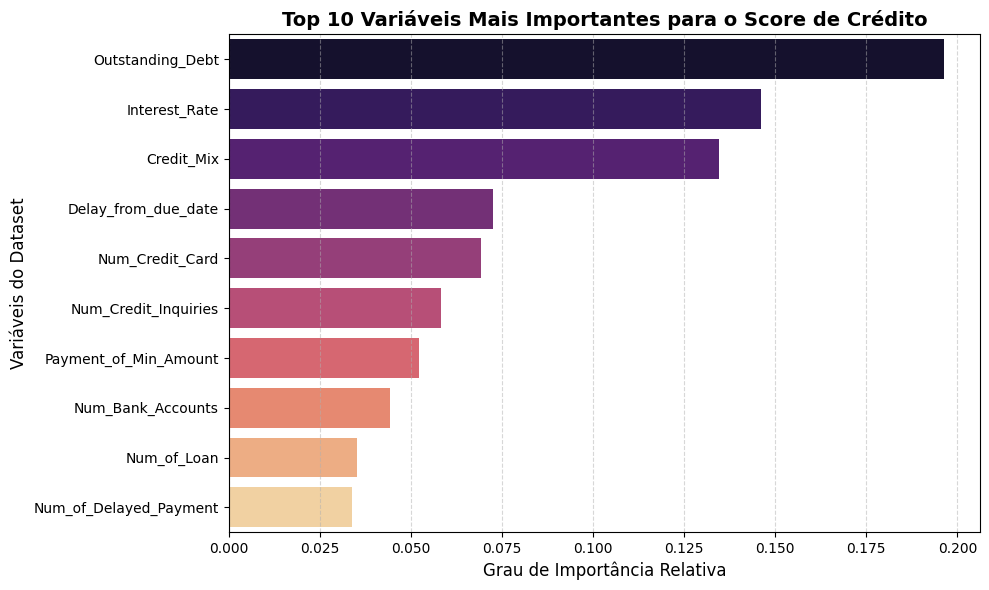

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importancias = modelo_floresta.feature_importances_

df_importancia = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancia.head(10),
    x='Importancia',
    y='Variavel',
    hue='Variavel',
    palette='magma',
    legend=False
)

plt.title('Top 10 Variáveis Mais Importantes para o Score de Crédito', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Importância Relativa', fontsize=12)
plt.ylabel('Variáveis do Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

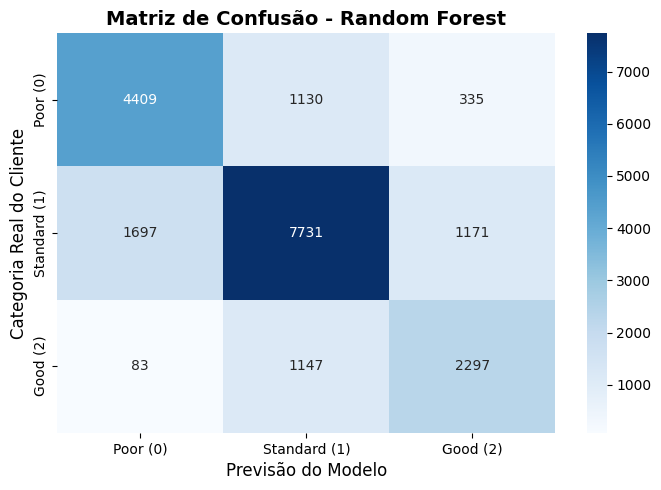

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusão comparando o gabarito real com as previsões da floresta
matriz = confusion_matrix(y_test, previsoes_floresta)

# Gráfico de mapa de calor (Heatmap)
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Poor (0)', 'Standard (1)', 'Good (2)'],
    yticklabels=['Poor (0)', 'Standard (1)', 'Good (2)']
)

plt.title('Matriz de Confusão - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Categoria Real do Cliente', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

parametros = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

# GridSearchCV
# cv=3 vai validar os dados dividindo-os em 3 partes (Cross-Validation)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=parametros,
                           cv=3,
                           scoring='accuracy',
                           n_jobs=-1)

print("Iniciando a busca exaustiva pelos melhores parâmetros (Tuning)...")
grid_search.fit(X_train, y_train)

print("\n--- Melhores Parâmetros Encontrados ---")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_
previsoes_tunadas = melhor_modelo.predict(X_test)
acuracia_tunada = accuracy_score(y_test, previsoes_tunadas)

print(f"\nAcurácia do Random Forest APÓS o Tuning: {acuracia_tunada * 100:.2f}%")

Iniciando a busca exaustiva pelos melhores parâmetros (Tuning)...

--- Melhores Parâmetros Encontrados ---
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 150}

Acurácia do Random Forest APÓS o Tuning: 74.09%


In [ ]:
!pip install shap

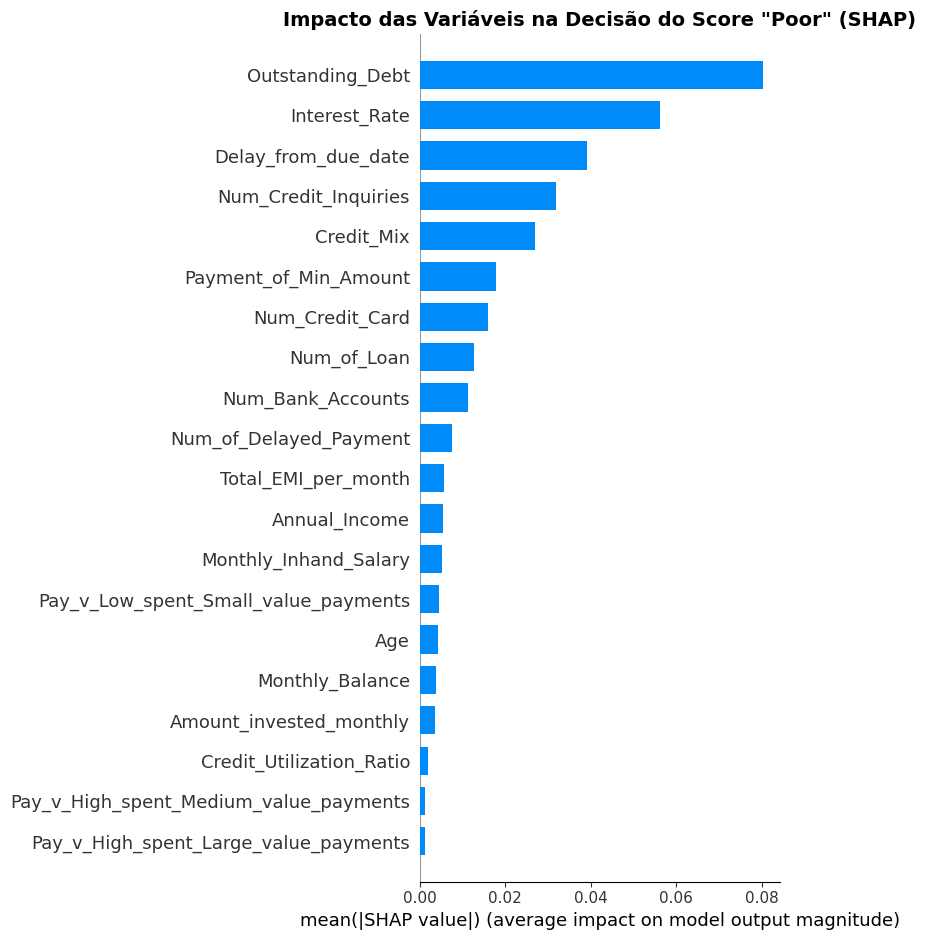

In [ ]:
import shap
import matplotlib.pyplot as plt


explicador = shap.TreeExplainer(melhor_modelo)
valores_shap = explicador(X_amostra)


plt.figure(figsize=(10, 6))

shap.summary_plot(valores_shap[:, :, 0], X_amostra, plot_type="bar", show=False)

plt.title('Impacto das Variáveis na Decisão do Score "Poor" (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()